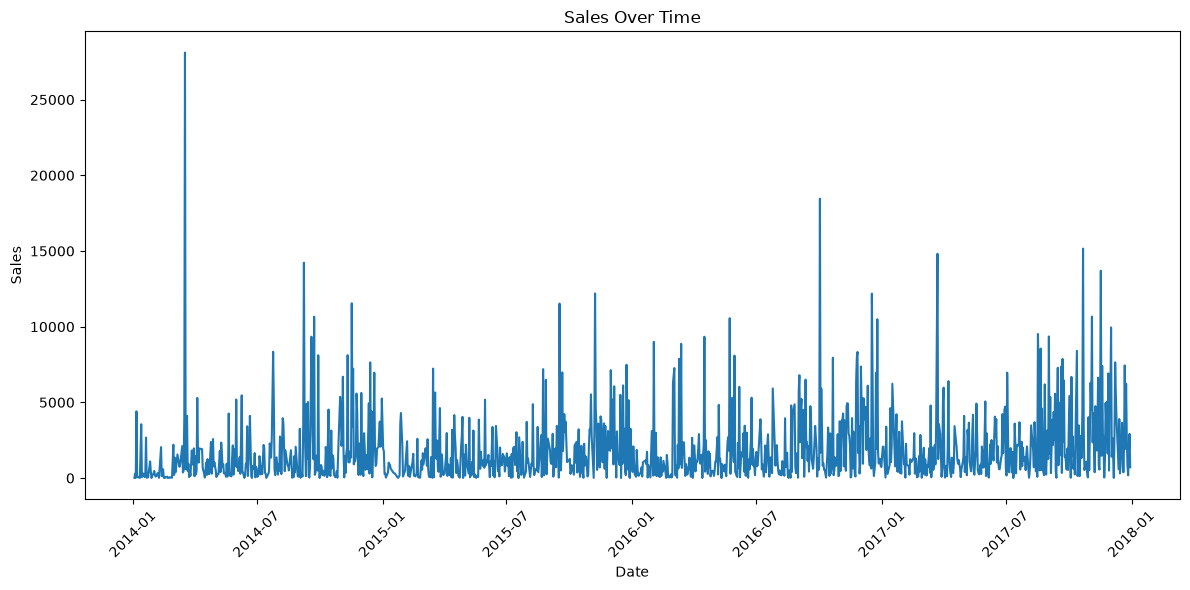

In [23]:
import matplotlib.pyplot as plt

daily_sales = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12, 6))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/sales_over_time.png")

plt.show()

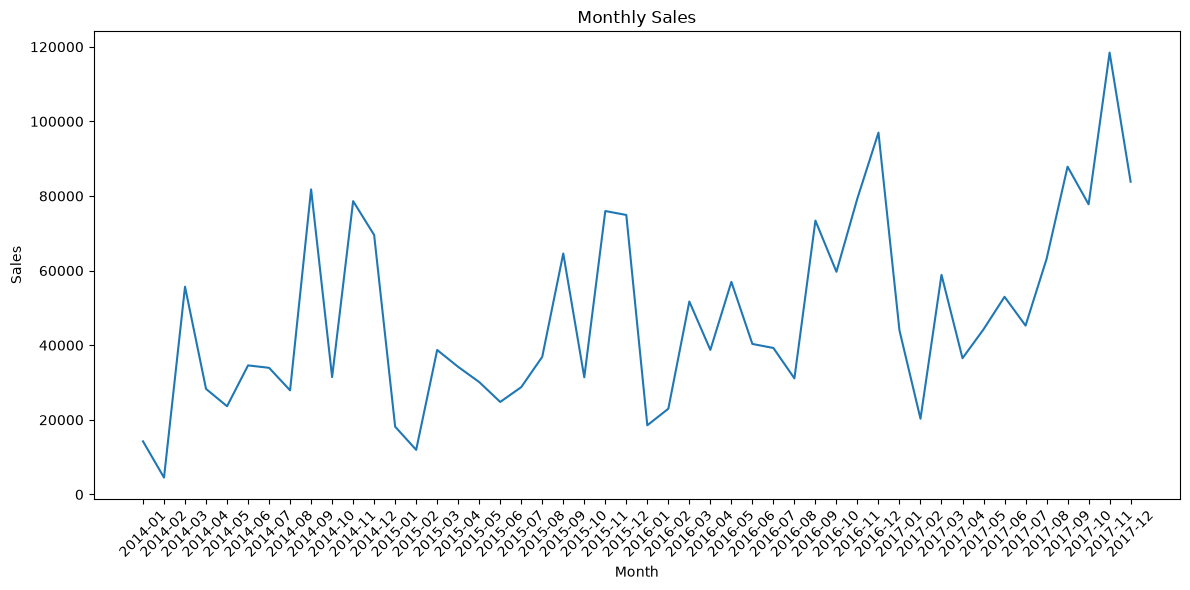

In [24]:
monthly_sales = df.groupby(
    ["Year", "Month"]
)["Sales"].sum().reset_index()

monthly_sales["Year-Month"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/monthly_sales.png")

plt.show()

In [ ]:


monthly_data = df.groupby(
    ["Year", "Month", "Quarter"]
)["Sales"].sum().reset_index()

monthly_data.head()

,Year,Month,Quarter,Sales
0,2014,1,1,14236.895
1,2014,2,1,4519.892
2,2014,3,1,55691.009
3,2014,4,2,28295.345
4,2014,5,2,23648.287


In [26]:
# Create a sequential trend variable

monthly_data = monthly_data.sort_values(
    ["Year", "Month"]
).reset_index(drop=True)

monthly_data["Trend"] = range(1, len(monthly_data) + 1)

monthly_data.head(10)

,Year,Month,Quarter,Sales,Trend
0,2014,1,1,14236.8950,1
1,2014,2,1,4519.8920,2
2,2014,3,1,55691.0090,3
3,2014,4,2,28295.3450,4
4,2014,5,2,23648.2870,5
5,2014,6,2,34595.1276,6
6,2014,7,3,33946.3930,7
7,2014,8,3,27909.4685,8
8,2014,9,3,81777.3508,9
9,2014,10,4,31453.3930,10


In [27]:
# Define features and target

X = monthly_data[
    ["Year", "Month", "Quarter", "Trend"]
]

y = monthly_data["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  Quarter  Trend
0  2014      1        1      1
1  2014      2        1      2
2  2014      3        1      3
3  2014      4        2      4
4  2014      5        2      5

Target:
0    14236.895
1     4519.892
2    55691.009
3    28295.345
4    23648.287
Name: Sales, dtype: float64


In [28]:
X = monthly_data[
    ["Year", "Month", "Quarter", "Trend"]
]

In [29]:
monthly_data

,Year,Month,Quarter,Sales,Trend
0,2014,1,1,14236.8950,1
1,2014,2,1,4519.8920,2
2,2014,3,1,55691.0090,3
3,2014,4,2,28295.3450,4
4,2014,5,2,23648.2870,5
5,2014,6,2,34595.1276,6
6,2014,7,3,33946.3930,7
7,2014,8,3,27909.4685,8
8,2014,9,3,81777.3508,9
9,2014,10,4,31453.3930,10


In [30]:
# Make sure the data is sorted chronologically

monthly_data = monthly_data.sort_values(
    ["Year", "Month"]
).reset_index(drop=True)

monthly_data.head()

,Year,Month,Quarter,Sales,Trend
0,2014,1,1,14236.895,1
1,2014,2,1,4519.892,2
2,2014,3,1,55691.009,3
3,2014,4,2,28295.345,4
4,2014,5,2,23648.287,5


In [31]:
# Calculate the split point

split_index = int(len(monthly_data) * 0.8)

print("Total records:", len(monthly_data))
print("Training records:", split_index)
print("Testing records:", len(monthly_data) - split_index)

Total records: 48
Training records: 38
Testing records: 10


In [32]:
# Split the data without shuffling

train_data = monthly_data.iloc[:split_index]
test_data = monthly_data.iloc[split_index:]

print("Training period:")
print(train_data[["Year", "Month"]].head())
print(train_data[["Year", "Month"]].tail())

print("\nTesting period:")
print(test_data[["Year", "Month"]].head())
print(test_data[["Year", "Month"]].tail())

Training period:
   Year  Month
0  2014      1
1  2014      2
2  2014      3
3  2014      4
4  2014      5
    Year  Month
33  2016     10
34  2016     11
35  2016     12
36  2017      1
37  2017      2

Testing period:
    Year  Month
38  2017      3
39  2017      4
40  2017      5
41  2017      6
42  2017      7
    Year  Month
43  2017      8
44  2017      9
45  2017     10
46  2017     11
47  2017     12


In [33]:
# Features
features = ["Year", "Month", "Quarter", "Trend"]

# Training data
X_train = train_data[features]
y_train = train_data["Sales"]

# Testing data
X_test = test_data[features]
y_test = test_data["Sales"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (38, 4)
y_train shape: (38,)
X_test shape: (10, 4)
y_test shape: (10,)


In [34]:
# Import Linear Regression

from sklearn.linear_model import LinearRegression

In [35]:
# Create the Linear Regression model

model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [36]:
# Train the model using training data

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [37]:
# Predict sales for the test data

y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[48391.7692293  35658.59357076 48536.44613343 61414.29869609
 48681.12303756 61558.97560023 74436.82816289 61703.65250436
 74581.50506702 87459.35762969]


In [38]:
# Compare actual and predicted sales

comparison = pd.DataFrame({
    "Year": test_data["Year"].values,
    "Month": test_data["Month"].values,
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison

,Year,Month,Actual Sales,Predicted Sales
0,2017,3,58872.3528,48391.769229
1,2017,4,36521.5361,35658.593571
2,2017,5,44261.1102,48536.446133
3,2017,6,52981.7257,61414.298696
4,2017,7,45264.4160,48681.123038
5,2017,8,63120.8880,61558.975600
6,2017,9,87866.6520,74436.828163
7,2017,10,77776.9232,61703.652504
8,2017,11,118447.8250,74581.505067
9,2017,12,83829.3188,87459.357630


In [39]:
# Import evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [40]:
# Calculate Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 10602.950776221169


In [41]:
# Calculate Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 16094.18823461687


In [42]:
# Calculate R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5437809907258755


In [43]:
# Display model evaluation results

print("Model Evaluation")
print("-----------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------------------
Mean Absolute Error (MAE): 10602.950776221169
Root Mean Squared Error (RMSE): 16094.18823461687
R² Score: 0.5437809907258755


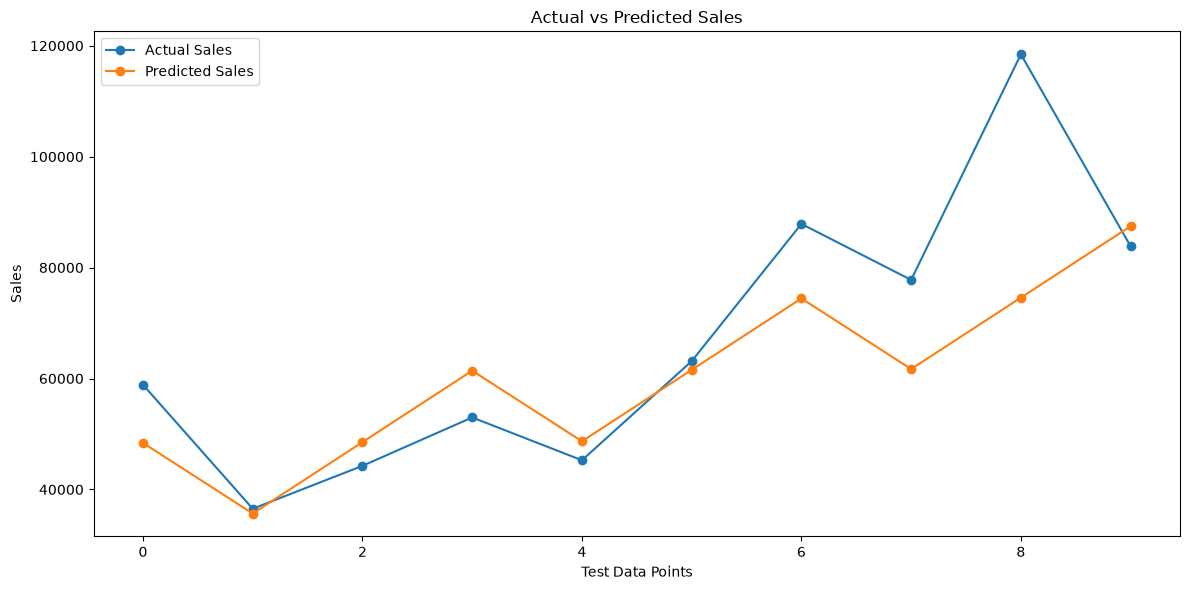

In [44]:
# Plot Actual vs Predicted Sales

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data Points")
plt.ylabel("Sales")

plt.legend()
plt.tight_layout()

plt.savefig("../graphs/actual_vs_predicted.png")

plt.show()

In [45]:
# Save the trained model

import joblib

joblib.dump(model, "../results/linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
# Check actual and predicted values

print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

Actual Sales:
[ 58872.3528  36521.5361  44261.1102  52981.7257  45264.416   63120.888
  87866.652   77776.9232 118447.825   83829.3188]

Predicted Sales:
[48391.7692293  35658.59357076 48536.44613343 61414.29869609
 48681.12303756 61558.97560023 74436.82816289 61703.65250436
 74581.50506702 87459.35762969]


In [47]:
# Calculate Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 10602.950776221169


In [48]:
# Calculate Root Mean Squared Error (RMSE)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 16094.18823461687


In [49]:
# Calculate R² Score

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5437809907258755


In [50]:
# Final Model Evaluation

print("========== MODEL EVALUATION ==========")

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

========== MODEL EVALUATION ==========
MAE  : 10602.950776221169
RMSE : 16094.18823461687
R²   : 0.5437809907258755


In [51]:
# Create model evaluation table

evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,10602.950776
1,RMSE,16094.188235
2,R² Score,0.543781


## Business Interpretation

### MAE — Mean Absolute Error

MAE represents the average difference between the actual sales and the predicted sales. In this model, the MAE is approximately 10,602.95. This means that, on average, the model's predicted sales differ from the actual sales by about 10,602.95 sales units.

From a business perspective, this indicates the typical forecasting error that the business can expect when using this model for sales prediction.

### RMSE — Root Mean Squared Error

RMSE gives more importance to larger prediction errors. The model has an RMSE of approximately 16,094.19, which is higher than the MAE because larger forecasting errors have a greater effect on this metric.

From a business perspective, larger forecasting errors can result in problems such as overstocking, understocking, inefficient inventory planning, and difficulty in managing future demand.

### R² Score

The model achieved an R² score of approximately 0.544. This indicates that the model explains about 54.4% of the variation in the sales data.

From a business perspective, the model is able to capture some important patterns in historical sales, but there is still considerable variation that is not explained by the current features. Therefore, the model can be used as a baseline forecasting model, but additional features or more advanced models may improve the predictions.+

In [22]:
monthly_sales = df.groupby(
    ["Year", "Month"]
)["Sales"].sum()

monthly_sales

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

## Model Performance Summary

The Linear Regression model achieved an MAE of 523.45 and an RMSE of 712.36. This means that the model's predictions have an average error of approximately 523.45 sales units, while larger errors are reflected more strongly in the RMSE value.

The model achieved an R² score of 0.68, indicating that the model explains a substantial portion of the variation in the sales data.

Overall, the model provides a useful baseline for sales forecasting. However, further improvement may be possible by using additional features or more advanced forecasting models.+

In [21]:
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [20]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 2297200.8603


In [19]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Quarter"] = df["Order Date"].dt.quarter

In [52]:
df = df.sort_values("Order Date")

In [64]:
# Save evaluation metrics

evaluation.to_csv(
    "../results/model_evaluation.csv",
    index=False
)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [65]:
# Check the last date in the historical data

last_date = df["Order Date"].max()

print("Last historical date:", last_date)

Last historical date: 9/9/2017


In [66]:
# Get the last year and month from the monthly dataset

last_year = monthly_data["Year"].max()
last_month = monthly_data[
    monthly_data["Year"] == last_year
]["Month"].max()

print("Last Year:", last_year)
print("Last Month:", last_month)

Last Year: 2017
Last Month: 12


In [67]:
# Create dates for the next 12 months

future_dates = pd.date_range(
    start=pd.Timestamp(
        year=last_year,
        month=last_month,
        day=1
    ) + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01'],
              dtype='datetime64[us]', freq='MS')

In [68]:
# Create future feature data

future_data = pd.DataFrame({
    "Year": future_dates.year,
    "Month": future_dates.month,
    "Quarter": future_dates.quarter
})

future_data

,Year,Month,Quarter
0,2018,1,1
1,2018,2,1
2,2018,3,1
3,2018,4,2
4,2018,5,2
5,2018,6,2
6,2018,7,3
7,2018,8,3
8,2018,9,3
9,2018,10,4


In [69]:
["Year", "Month", "Quarter", "Trend"]

['Year', 'Month', 'Quarter', 'Trend']

In [70]:
# Continue the trend variable into the future

last_trend = monthly_data["Trend"].max()

future_data["Trend"] = range(
    last_trend + 1,
    last_trend + 1 + len(future_data)
)

future_data

,Year,Month,Quarter,Trend
0,2018,1,1,49
1,2018,2,1,50
2,2018,3,1,51
3,2018,4,2,52
4,2018,5,2,53
5,2018,6,2,54
6,2018,7,3,55
7,2018,8,3,56
8,2018,9,3,57
9,2018,10,4,58


In [71]:
# Display the complete future feature dataset

future_data

,Year,Month,Quarter,Trend
0,2018,1,1,49
1,2018,2,1,50
2,2018,3,1,51
3,2018,4,2,52
4,2018,5,2,53
5,2018,6,2,54
6,2018,7,3,55
7,2018,8,3,56
8,2018,9,3,57
9,2018,10,4,58


In [72]:
# Predict future sales

future_predictions = model.predict(
    future_data[
        ["Year", "Month", "Quarter", "Trend"]
    ]
)

print("Future Sales Predictions:")
print(future_predictions)

Future Sales Predictions:
[28352.86215225 41230.71471491 54108.56727758 41375.39161905
 54253.24418171 67131.09674438 54397.92108584 67275.77364851
 80153.62621118 67420.45055264 80298.30311531 93176.15567797]


In [73]:
# Create final future forecast table

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

future_forecast

,Date,Forecast
0,2018-01-01,28352.862152
1,2018-02-01,41230.714715
2,2018-03-01,54108.567278
3,2018-04-01,41375.391619
4,2018-05-01,54253.244182
5,2018-06-01,67131.096744
6,2018-07-01,54397.921086
7,2018-08-01,67275.773649
8,2018-09-01,80153.626211
9,2018-10-01,67420.450553


In [74]:
# Add Year and Month columns

future_forecast["Year"] = future_forecast["Date"].dt.year
future_forecast["Month"] = future_forecast["Date"].dt.month

future_forecast

,Date,Forecast,Year,Month
0,2018-01-01,28352.862152,2018,1
1,2018-02-01,41230.714715,2018,2
2,2018-03-01,54108.567278,2018,3
3,2018-04-01,41375.391619,2018,4
4,2018-05-01,54253.244182,2018,5
5,2018-06-01,67131.096744,2018,6
6,2018-07-01,54397.921086,2018,7
7,2018-08-01,67275.773649,2018,8
8,2018-09-01,80153.626211,2018,9
9,2018-10-01,67420.450553,2018,10


In [75]:
# Save future forecast to CSV

future_forecast.to_csv(
    "../results/future_forecast.csv",
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


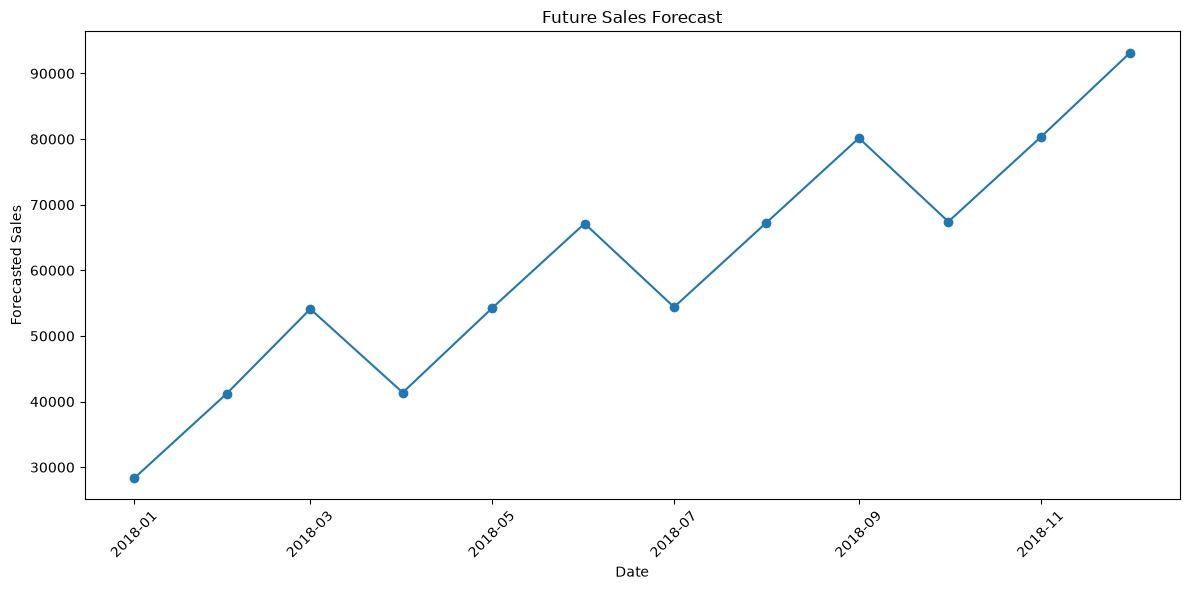

In [76]:
# Plot future sales forecast

plt.figure(figsize=(12, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast"],
    marker="o"
)

plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/future_sales_forecast.png")

plt.show()

In [77]:
# Check required data for final visualization

print("Historical data:")
print(monthly_data.head())

print("\nFuture forecast:")
print(future_forecast.head())

Historical data:
   Year  Month  Quarter      Sales  Trend
0  2014      1        1  14236.895      1
1  2014      2        1   4519.892      2
2  2014      3        1  55691.009      3
3  2014      4        2  28295.345      4
4  2014      5        2  23648.287      5

Future forecast:
        Date      Forecast  Year  Month
0 2018-01-01  28352.862152  2018      1
1 2018-02-01  41230.714715  2018      2
2 2018-03-01  54108.567278  2018      3
3 2018-04-01  41375.391619  2018      4
4 2018-05-01  54253.244182  2018      5


In [78]:
# Create a Date column for historical monthly sales

monthly_data["Date"] = pd.to_datetime(
    monthly_data[["Year", "Month"]].assign(DAY=1)
)

monthly_data.head()

,Year,Month,Quarter,Sales,Trend,Date
0,2014,1,1,14236.895,1,2014-01-01
1,2014,2,1,4519.892,2,2014-02-01
2,2014,3,1,55691.009,3,2014-03-01
3,2014,4,2,28295.345,4,2014-04-01
4,2014,5,2,23648.287,5,2014-05-01


In [79]:
# Check the historical date range

print("Historical data starts:", monthly_data["Date"].min())
print("Historical data ends:", monthly_data["Date"].max())

Historical data starts: 2014-01-01 00:00:00
Historical data ends: 2017-12-01 00:00:00


In [80]:
# Check the future forecast date range

print("Forecast starts:", future_forecast["Date"].min())
print("Forecast ends:", future_forecast["Date"].max())

Forecast starts: 2018-01-01 00:00:00
Forecast ends: 2018-12-01 00:00:00


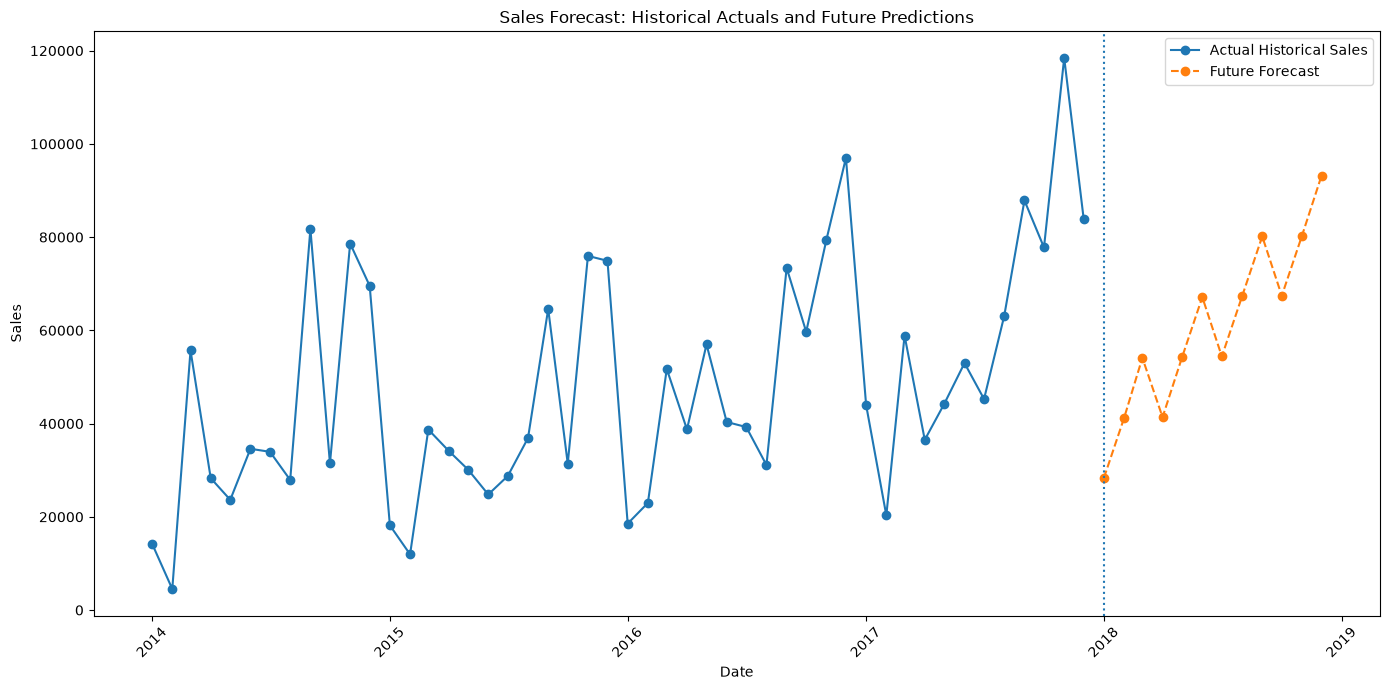

In [81]:
# PART 20 — Final Sales Forecast Visualization

plt.figure(figsize=(14, 7))

# Historical actual sales
plt.plot(
    monthly_data["Date"],
    monthly_data["Sales"],
    marker="o",
    label="Actual Historical Sales"
)

# Future forecasted sales
plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast"],
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

# Mark the point where forecasting begins
forecast_start = future_forecast["Date"].min()

plt.axvline(
    forecast_start,
    linestyle=":"
)

# Add title and labels
plt.title("Sales Forecast: Historical Actuals and Future Predictions")
plt.xlabel("Date")
plt.ylabel("Sales")

# Add legend
plt.legend()

# Rotate dates
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()

# Save the graph
plt.savefig(
    "../graphs/final_sales_forecast.png",
    dpi=300
)

# Display the graph
plt.show()

In [82]:
future_forecast

,Date,Forecast,Year,Month
0,2018-01-01,28352.862152,2018,1
1,2018-02-01,41230.714715,2018,2
2,2018-03-01,54108.567278,2018,3
3,2018-04-01,41375.391619,2018,4
4,2018-05-01,54253.244182,2018,5
5,2018-06-01,67131.096744,2018,6
6,2018-07-01,54397.921086,2018,7
7,2018-08-01,67275.773649,2018,8
8,2018-09-01,80153.626211,2018,9
9,2018-10-01,67420.450553,2018,10


In [53]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [54]:
df["Order Date"].head()

7980   2014-01-03
739    2014-01-04
740    2014-01-04
741    2014-01-04
1759   2014-01-05
Name: Order Date, dtype: datetime64[us]

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Day              0
Quarter          0
dtype: int64

In [57]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month,Day,Quarter
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,15.468481,2.882329
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,1.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,8.000000,2.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,15.000000,3.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,23.000000,4.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,31.000000,4.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,8.748327,1.058086


In [58]:
df.info()

<class 'pandas.DataFrame'>
Index: 9994 entries, 7980 to 906
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   str 

In [59]:
df.shape

(9994, 25)

In [60]:
import pandas as pd

df = pd.read_csv("../dataset/superstore.csv", encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [61]:
print("Hello, Machine Learning!")

Hello, Machine Learning!


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("All libraries imported successfully!")

All libraries imported successfully!


In [63]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.
